<a href="https://colab.research.google.com/github/eiyu18/pcvk/blob/main/week5_10_244107020181.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Eiyu Azizuly Efendi'
NIM  = '244107020181'
N     = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Eiyu Azizuly Efendi
NIM    : 244107020181 | N = 181
bins   : 16
clip   : 1.5
tile   : 3
L      : 4
WAKTU  : 2026-09-30 18:57:40 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : ab3efe7533652051


E-1 PERCOBAAN HISTOGRAM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

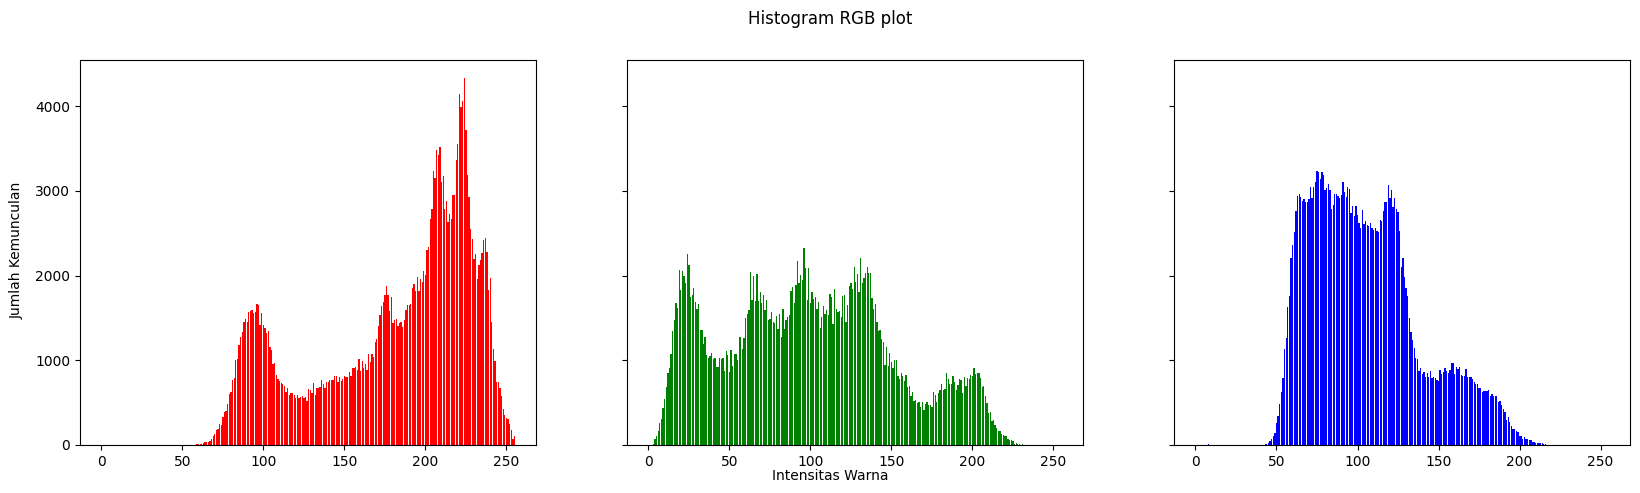

In [5]:
img = cv.imread('/content/sample_data/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0, width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig. suptitle('Histogram RGB plot')
fig. text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig. text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs [1] .bar(names, green, color='green')
axs [2] .bar(names, blue, color='blue')

E-2 PERCOBAAN HISTOGRAM EQUALIZATION

/tmp/ipykernel_2565/3224861608.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1,0].hist(gray.ravel(), 256, (0,256), color='gray'); axs[1,0].set_title('Histogram asli')
/tmp/ipykernel_2565/3224861608.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1,1].hist(he.ravel(),   256, (0,256), color='gray'); axs[1,1].set_title('Histogram HE')


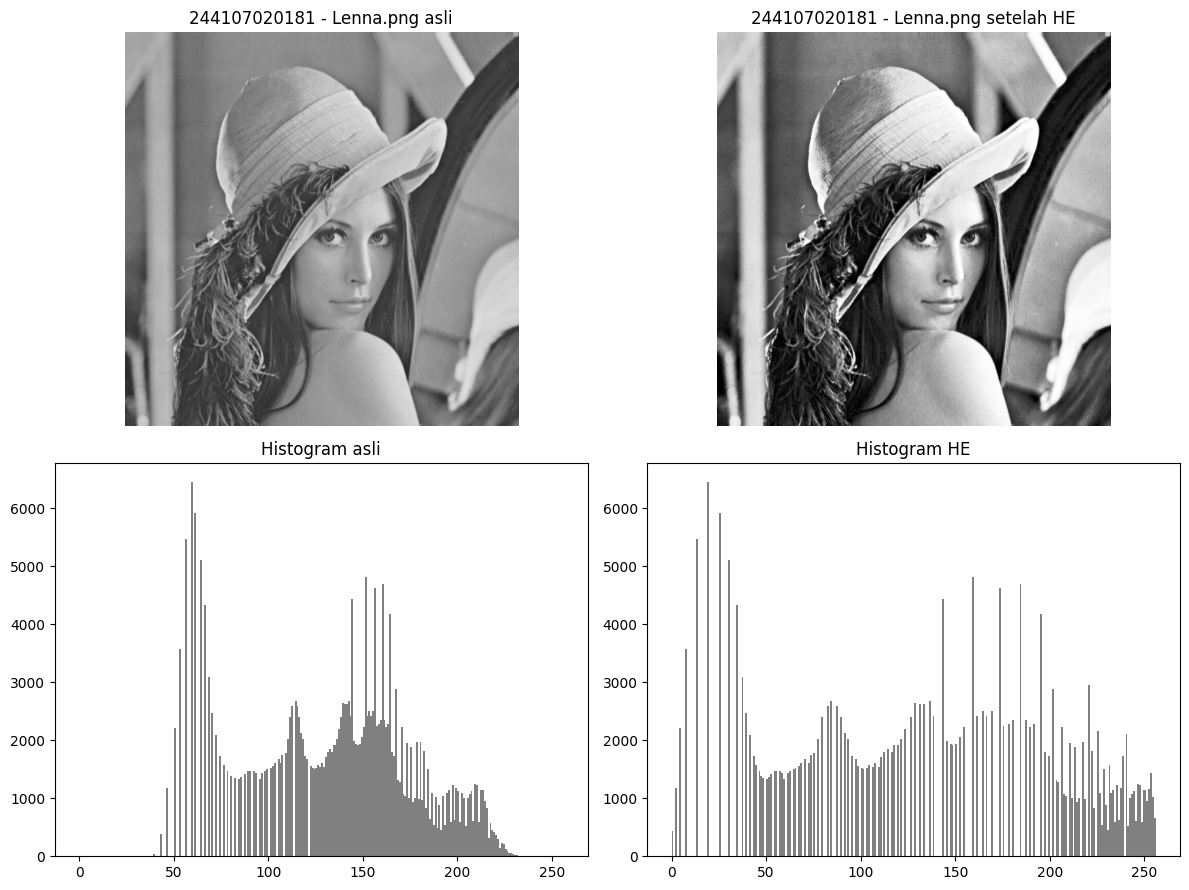

Lenna.png | selisih maks manual vs equalizeHist = 1


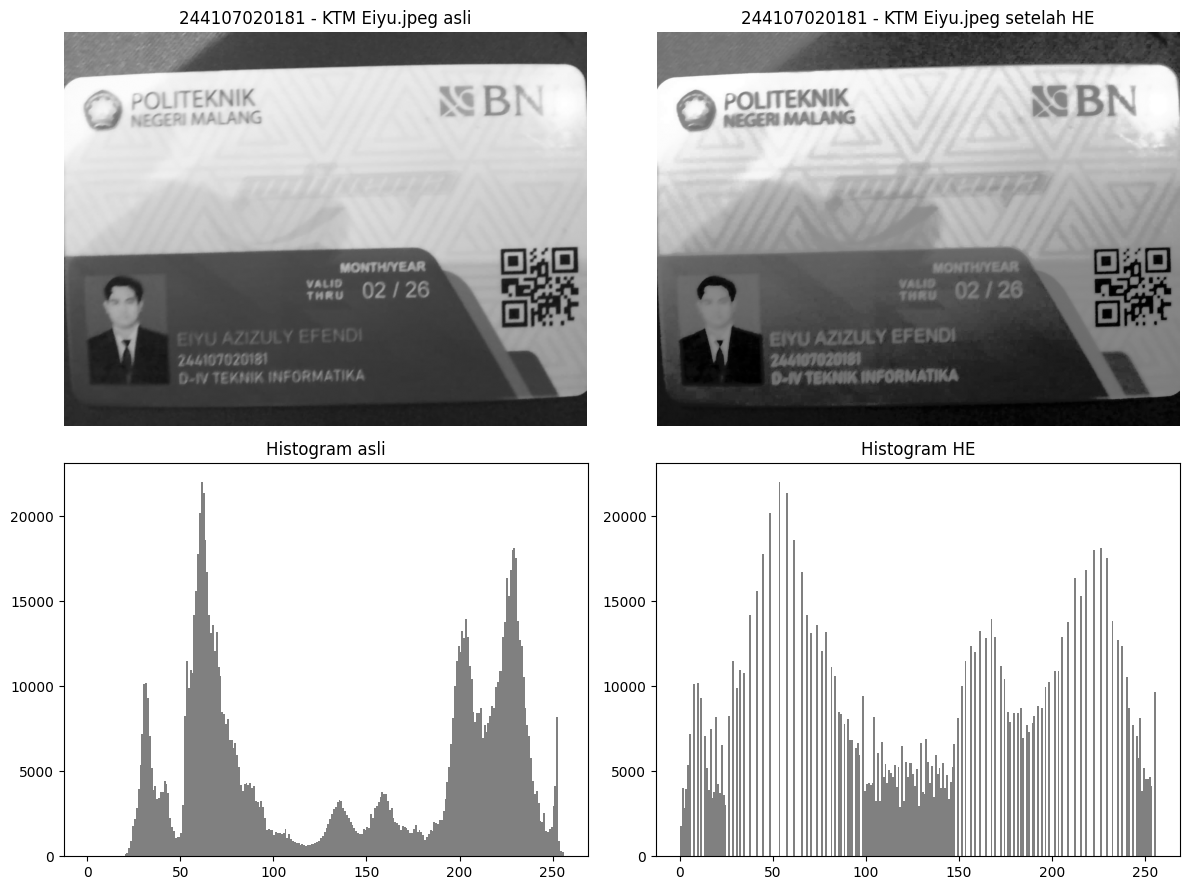

KTM Eiyu.jpeg | selisih maks manual vs equalizeHist = 0


In [8]:
def he_manual(gray):
    h   = np.bincount(gray.ravel(), minlength=256)
    cdf = np.cumsum(h)
    lut = np.round(cdf * 255 / gray.size).astype(np.uint8)
    return lut[gray]

def tampil_he(gray, judul):
    he = he_manual(gray)
    fig, axs = plt.subplots(2, 2, figsize=(12, 9))
    axs[0,0].imshow(gray, cmap='gray', vmin=0, vmax=255); axs[0,0].set_title(NIM + ' - ' + judul + ' asli')
    axs[0,1].imshow(he,   cmap='gray', vmin=0, vmax=255); axs[0,1].set_title(NIM + ' - ' + judul + ' setelah HE')
    axs[1,0].hist(gray.ravel(), 256, (0,256), color='gray'); axs[1,0].set_title('Histogram asli')
    axs[1,1].hist(he.ravel(),   256, (0,256), color='gray'); axs[1,1].set_title('Histogram HE')
    for a in axs.ravel()[:2]: a.axis('off')
    plt.tight_layout(); plt.show()

    cvhe = cv.equalizeHist(gray)
    print(judul, '| selisih maks manual vs equalizeHist =', np.abs(he.astype(int) - cvhe.astype(int)).max())
    return he, cvhe

he_lena, _ = tampil_he(cv.imread('/content/sample_data/Lenna.png', cv.IMREAD_GRAYSCALE), 'Lenna.png')
he_ktm, cvhe_ktm = tampil_he(cv.imread('/content/drive/MyDrive/pcvk/Gambar/KTM_Eiyu.jpeg', cv.IMREAD_GRAYSCALE), 'KTM Eiyu.jpeg')

Ekualisasi berwarna (E-2 no. 3 dan 4) - tahap 1: lena.jpg, tahap 2: KTM1d.jpg

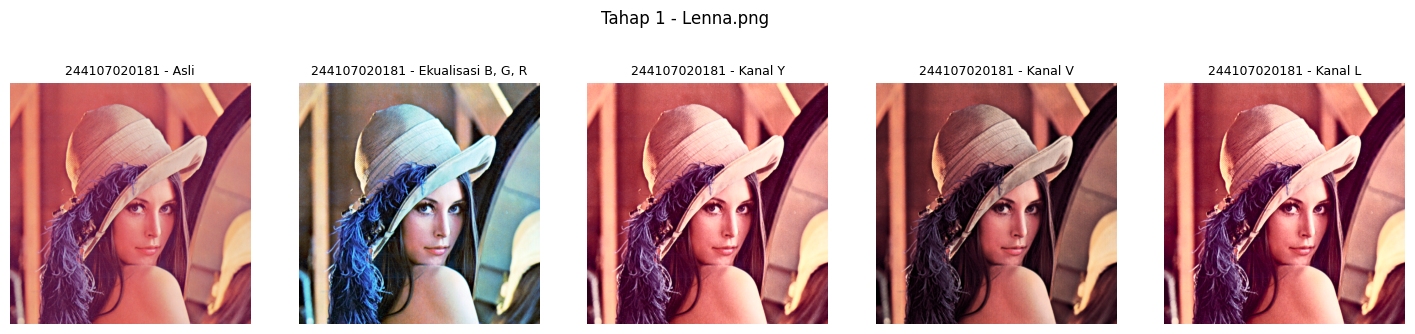

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            124.0
Ekualisasi B, G, R                74.86            128.3
Kanal Y                            2.02            128.0
Kanal V                            0.68             91.2
Kanal L                            2.61            121.6


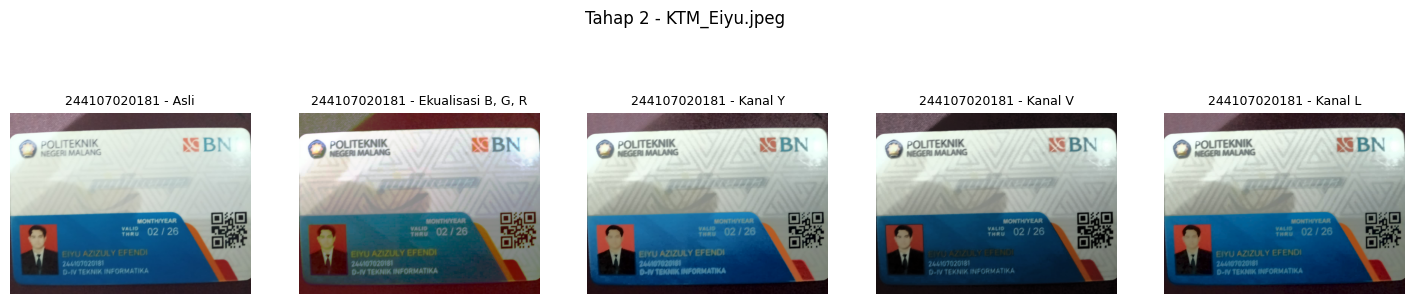

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            141.9
Ekualisasi B, G, R                43.48            128.5
Kanal Y                            0.52            128.7
Kanal V                            2.06            114.2
Kanal L                            3.06            120.3


In [10]:
def ekualisasi_warna(berkas, tag):
    # Mengganti baca_bgr dengan cv.imread standar
    bgr = cv.imread(berkas)

    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    y, cr, cb = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb))
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    h, sat, v = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2HSV))
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    l, a, b = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2LAB))
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + t, fontsize=9)
        plt.axis('off')
    plt.suptitle(tag); plt.show()
    return bgr, judul, citra

def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

def tabel(bgr, judul, citra):
    print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
    for t, c in zip(judul, citra):
        print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
              cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

# Menghapus CONTOH + dan BASE + karena path yang diberikan sudah absolut
b1, j1, c1 = ekualisasi_warna('/content/sample_data/Lenna.png', 'Tahap 1 - Lenna.png')
tabel(b1, j1, c1)

bgr, judul, citra = ekualisasi_warna('/content/drive/MyDrive/pcvk/Gambar/KTM_Eiyu.jpeg', 'Tahap 2 - KTM_Eiyu.jpeg')
tabel(bgr, judul, citra)

E-2 no. 4: CLAHE pada kanal terang (Y) dengan parameter NIM

Cara                    geser Hue (der)    rerata terang
Y biasa                            0.52            128.7
Y CLAHE                            0.07            138.3


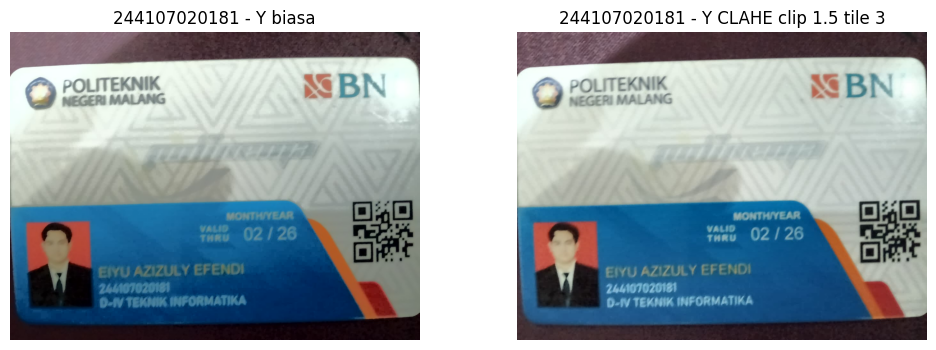

In [11]:
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
y, cr, cb = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb))
he_clahe = cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in [('Y biasa', citra[2]), ('Y CLAHE', he_clahe)]:
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

plt.figure(figsize=(12, 4))
for i, (c, t) in enumerate([(citra[2], 'Y biasa'), (he_clahe, 'Y CLAHE clip %s tile %d' % (PARAM['clip'], PARAM['tile']))], 1):
    plt.subplot(1, 2, i); plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - ' + t); plt.axis('off')
plt.show()

Pertanyaan E2 no. 1: ekualisasi global + PSNR (KTM1a grayscale)

PSNR asli vs HE manual    : 21.11 dB
PSNR asli vs equalizeHist : 21.11 dB
Kontras (std) asli = 75.8 | HE = 73.6


/tmp/ipykernel_2565/1967771752.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1,0].hist(g.ravel(), 256, (0,256), color='gray'); axs[1,0].set_title('Histogram asli')
/tmp/ipykernel_2565/1967771752.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1,1].hist(he_cv.ravel(), 256, (0,256), color='gray'); axs[1,1].set_title('Histogram HE')


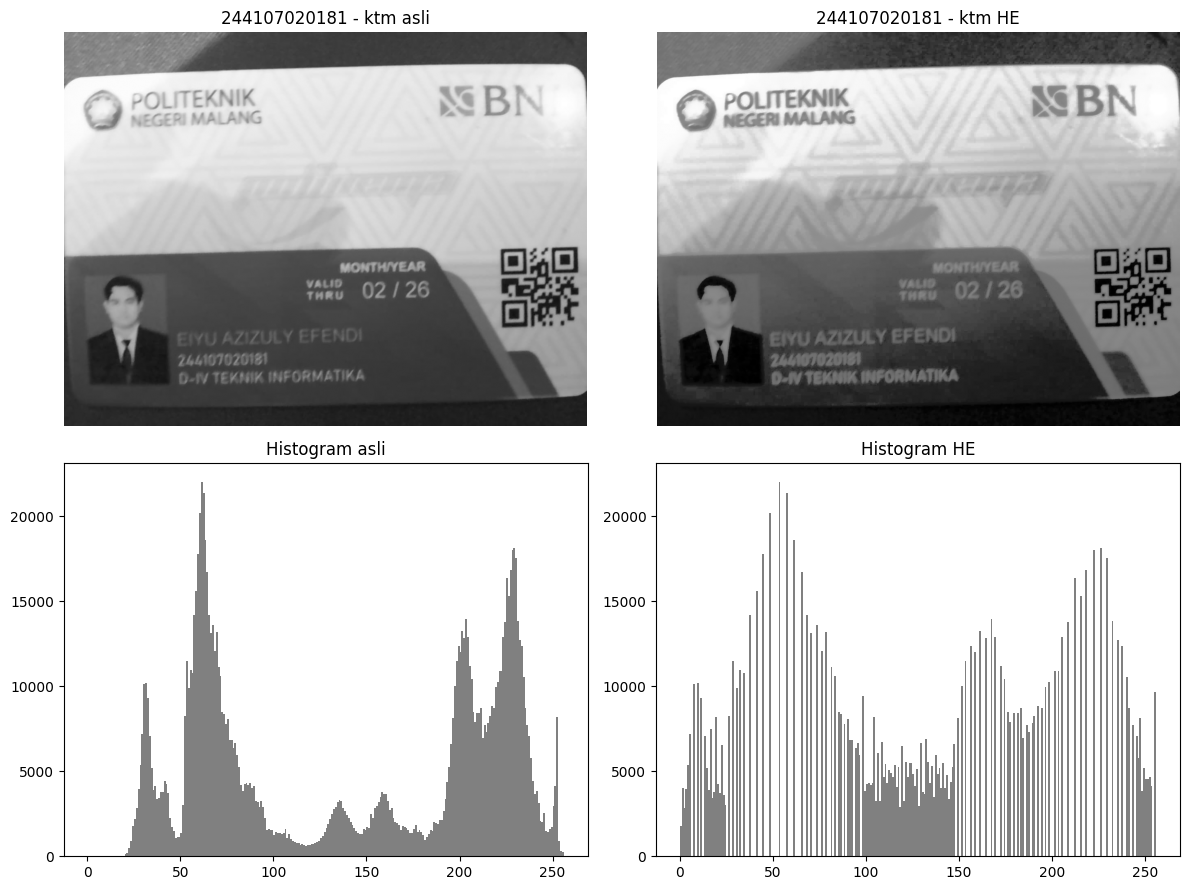

In [14]:
g = cv.imread('/content/drive/MyDrive/pcvk/Gambar/KTM_Eiyu.jpeg', cv.IMREAD_GRAYSCALE)

he_m  = he_manual(g)
he_cv = cv.equalizeHist(g)

def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

print('PSNR asli vs HE manual    : %.2f dB' % psnr(g, he_m))
print('PSNR asli vs equalizeHist : %.2f dB' % psnr(g, he_cv))
print('Kontras (std) asli = %.1f | HE = %.1f' % (g.std(), he_m.std()))

fig, axs = plt.subplots(2, 2, figsize=(12, 9))
axs[0,0].imshow(g, cmap='gray', vmin=0, vmax=255); axs[0,0].set_title(NIM + ' - ktm asli'); axs[0,0].axis('off')
axs[0,1].imshow(he_cv, cmap='gray', vmin=0, vmax=255); axs[0,1].set_title(NIM + ' - ktm HE'); axs[0,1].axis('off')
axs[1,0].hist(g.ravel(), 256, (0,256), color='gray'); axs[1,0].set_title('Histogram asli')
axs[1,1].hist(he_cv.ravel(), 256, (0,256), color='gray'); axs[1,1].set_title('Histogram HE')
plt.tight_layout(); plt.show()

Pertanyaan E2 no. 2: CLAHE vs global, dan variasi clipLimit

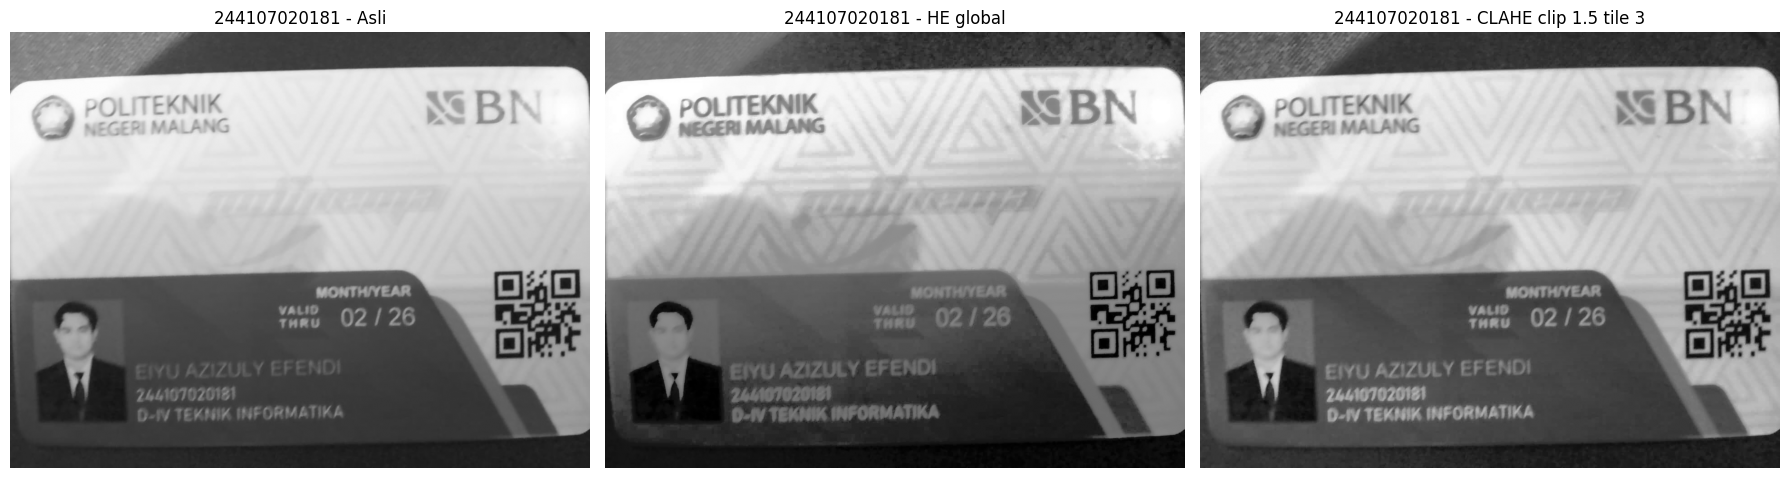

Kandidat clipLimit: [1.0, 2.0, 2.5]


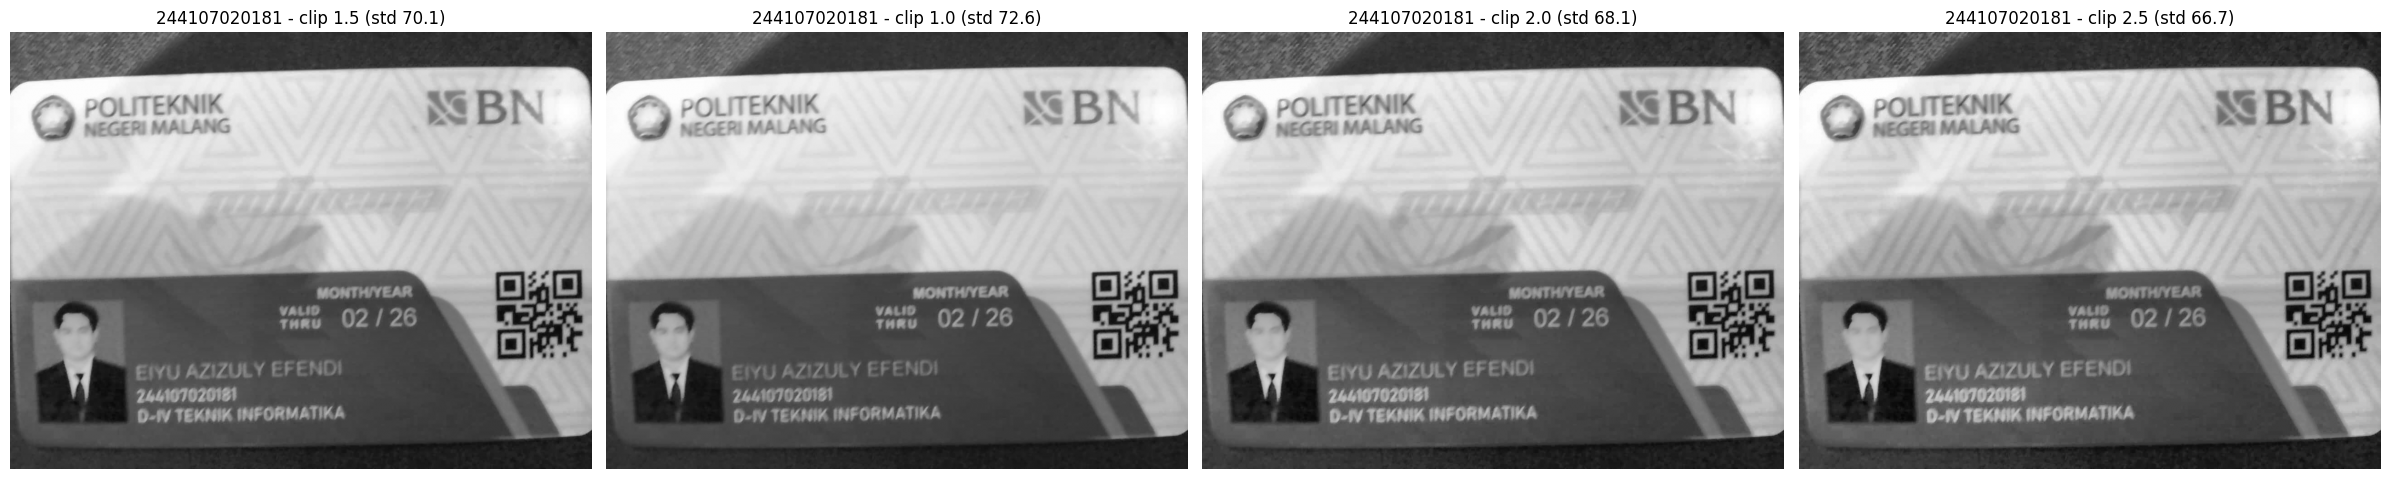

In [15]:
def clahe_gray(img, clip, tile):
    return cv.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile)).apply(img)

hasil_clahe = clahe_gray(g, PARAM['clip'], PARAM['tile'])
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for ax, (c, t) in zip(axs, [(g, 'Asli'), (he_cv, 'HE global'), (hasil_clahe, 'CLAHE clip %s tile %d' % (PARAM['clip'], PARAM['tile']))]):
    ax.imshow(c, cmap='gray', vmin=0, vmax=255); ax.set_title(NIM + ' - ' + t); ax.axis('off')
plt.tight_layout(); plt.show()

kandidat = sorted({round(max(1.0, PARAM['clip'] + d), 1) for d in (-1.0, -0.5, 0.5, 1.0, 2.0)} - {PARAM['clip']})[:3]
print('Kandidat clipLimit:', kandidat)
fig, axs = plt.subplots(1, len(kandidat) + 1, figsize=(6 * (len(kandidat) + 1), 6))
for ax, cl in zip(axs, [PARAM['clip']] + kandidat):
    out = clahe_gray(g, cl, PARAM['tile'])
    ax.imshow(out, cmap='gray', vmin=0, vmax=255); ax.set_title('%s - clip %.1f (std %.1f)' % (NIM, cl, out.std())); ax.axis('off')
plt.tight_layout(); plt.show()

E-3 Dithering Floyd-Steinberg

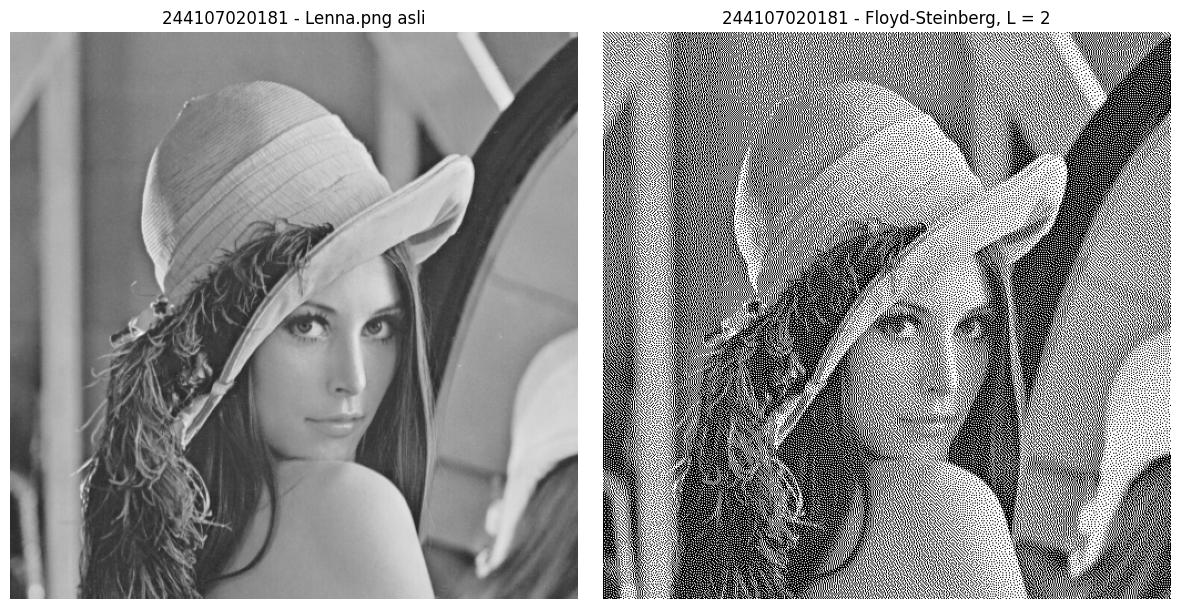

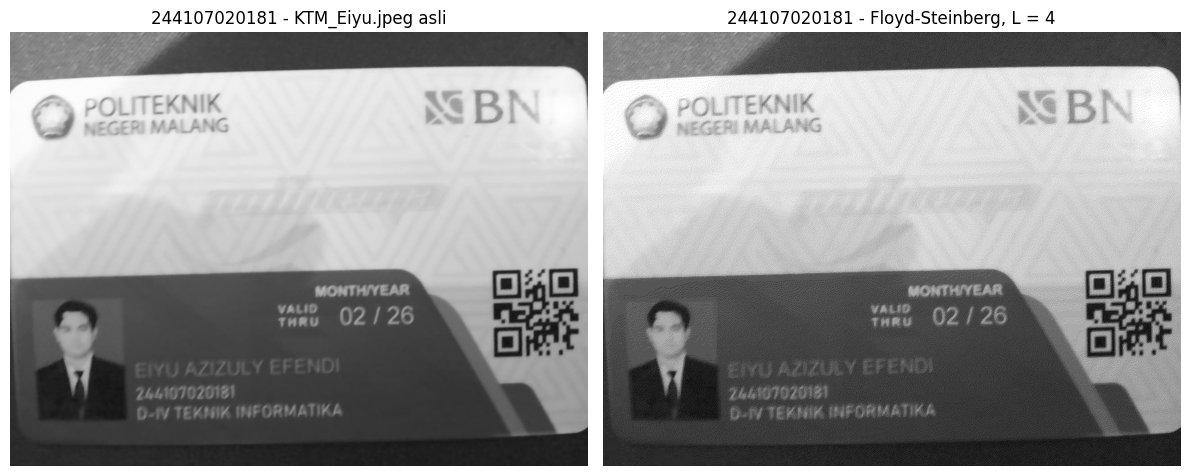

In [17]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:               img[y,   x+1] += error * 7 / 16
            if x > 0 and y + 1 < H:     img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:               img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y + 1 < H: img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

def dither_tampil(path, L, judul):
    # Mengganti baca_gray dengan cv.imread standar
    gr = cv.imread(path, cv.IMREAD_GRAYSCALE)

    d = floyd_steinberg(gr, L)
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(gr, cmap='gray', vmin=0, vmax=255); axs[0].set_title(NIM + ' - ' + judul + ' asli')
    axs[1].imshow(d,  cmap='gray', vmin=0, vmax=255); axs[1].set_title(NIM + ' - Floyd-Steinberg, L = %d' % L)
    for a in axs: a.axis('off')
    plt.tight_layout(); plt.show()

# Menghapus CONTOH + dan BASE + dari argumen pemanggilan fungsi
dither_tampil('/content/sample_data/Lenna.png', 2, 'Lenna.png')
dither_tampil('/content/drive/MyDrive/pcvk/Gambar/KTM_Eiyu.jpeg', PARAM['L'], 'KTM_Eiyu.jpeg')

E-3-2: ekualisasi lalu dithering vs dithering langsung

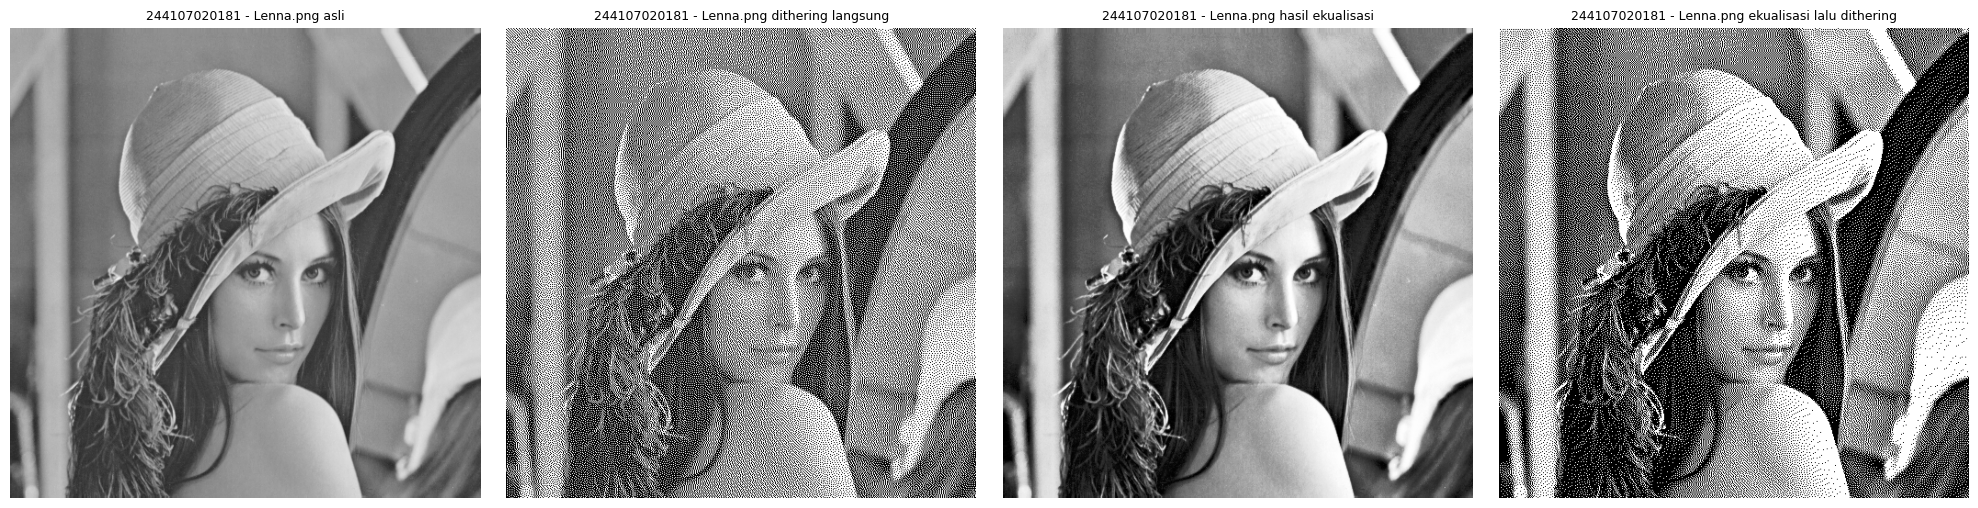

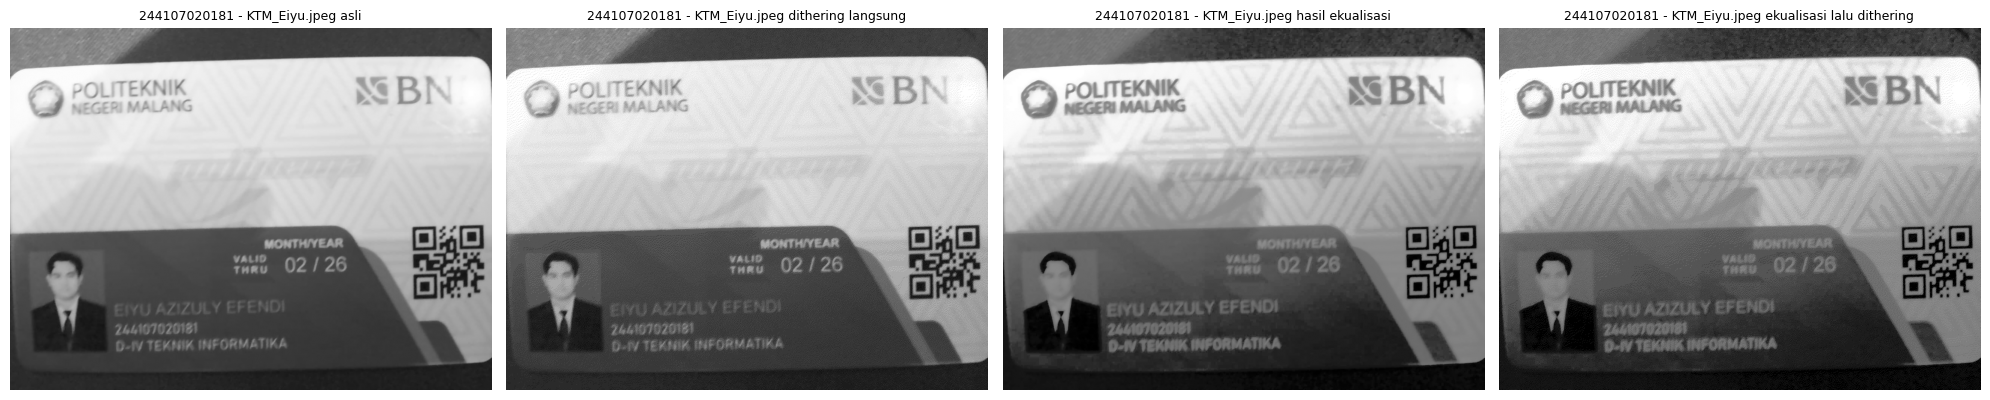

In [20]:
def urutan(path, L, judul):
    gr = cv.imread(path, cv.IMREAD_GRAYSCALE)

    langsung = floyd_steinberg(gr, L)
    he = cv.equalizeHist(gr)
    he_dith = floyd_steinberg(he, L)

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    for ax, (c, t) in zip(axs, [(gr, 'asli'), (langsung, 'dithering langsung'),
                                (he, 'hasil ekualisasi'), (he_dith, 'ekualisasi lalu dithering')]):
        ax.imshow(c, cmap='gray', vmin=0, vmax=255)
        ax.set_title(NIM + ' - ' + judul + ' ' + t, fontsize=9)
        ax.axis('off')
    plt.tight_layout(); plt.show()

urutan('/content/sample_data/Lenna.png', 2, 'Lenna.png')
urutan('/content/drive/MyDrive/pcvk/Gambar/KTM_Eiyu.jpeg', PARAM['L'], 'KTM_Eiyu.jpeg')